In [1]:
## In this tutorial, we will use the data discussed in previous tutorials to get the broader perspective.  

In [2]:
import os
import scope
from scope.read_write import *

In [3]:
## Path of the data folder. It should be "os.path.abspath('.')+'/Data"
data_folder = os.path.abspath('.')+'/Data/'
## Loads the System object from a binary file, provided in the tutorial folder
sys = load_binary(f"{data_folder}ABITEM.npy")

In [4]:
mol    = sys.find_source("ref_hs_mol")[1]
istate = mol.find_state("initial")[1]
fstate = mol.find_state("b3lyp_opt")[1]
print(mol)

--------------------------------------------------
------------- SCOPE MOLECULE Object --------------
--------------------------------------------------
 Version               = 1.0
 Type                  = specie
 Sub-Type              = molecule
 Number of Atoms       = 47
 Formula               = H18-C20-N6-S2-Fe
 Charge                = 0
 Spin                  = 4
 SMILES                = ['[N-]=C=S', '[H]c1nc(C([H])([H])N(C([H])([H])c2nc([H])c([H])c([H])c2[H])C([H])([H])c2nc([H])c([H])c([H])c2[H])c([H])c([H])c1[H]', '[N-]=C=S']
 Number of Parents     = 1
 Has Adjacency Matrix  = YES
 Has Bonds             = YES
 # Ligands             = 3
 # Metals              = 1




In [11]:
opt_comp = fstate.computations[0]
out = opt_comp.create_output()
all_labels, all_geoms = out.get_all_geometries()
all_energies          = out.get_all_energies()
print(len(all_energies), len(all_geoms))


57 57


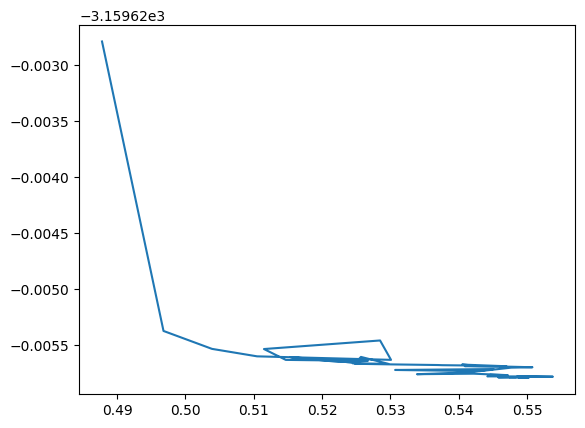

In [ ]:
from scope.other import rmsd
import matplotlib.pyplot as plt
rmsd_vals = []
for l in zip(all_labels, all_geoms, all_energies):
    rmsd_vals.append(rmsd(mol.labels, mol.coord, l[0], l[1]))
plt.plot(rmsd_vals, all_energies)


In [7]:
mol2 = fstate.moleclist[0]
print(mol2)

--------------------------------------------------
------------- SCOPE MOLECULE Object --------------
--------------------------------------------------
 Version               = 1.0
 Type                  = specie
 Sub-Type              = molecule
 Number of Atoms       = 47
 Formula               = H18-C20-N6-S2-Fe
 Charge                = 0
 Spin                  = 0
 Number of Parents     = 2
 Has Adjacency Matrix  = YES
 Has Bonds             = NO
 # Ligands             = 3
 # Metals              = 1




In [8]:
mol == mol2

True

In [9]:
mol.rmsd(mol2)

0.5486